In [1]:
import numpy as np
from scipy import signal as sig
from matplotlib import pyplot as plt

import utilities as utils

In [2]:
def read_datafile(name: str, sep: str=' '):
    return np.loadtxt('./data/' + name + '.csv', delimiter=sep, skiprows=1, dtype=np.float32)

def butter_lowpass_filter(data, cutoff, fs, order=5):
    nyq = 0.5 * fs  # Nyquist frequency
    normal_cutoff = cutoff / nyq
    b, a = sig.butter(order, normal_cutoff, btype='low', analog=False)
    y = sig.filtfilt(b, a, data)  # zero-phase filtering
    return y

(10000, 2)


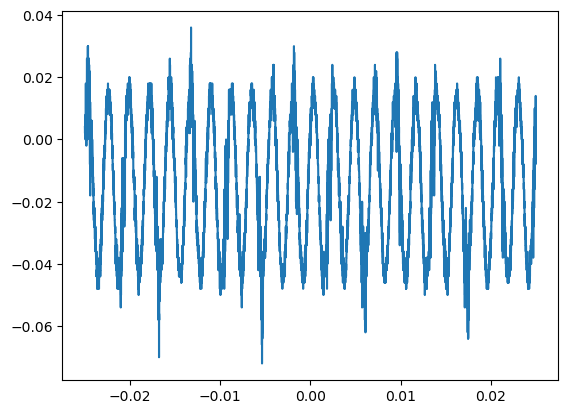

In [3]:
# --! read raw data from a file -----------------------------------------------

raw_data = read_datafile('WFM01', sep=',')
print(raw_data.shape)

# --! extract time and voltage
t = raw_data[:, 0]
v = raw_data[:, 1]

# --! sampling frequency
fs = 200_000

plt.figure()
plt.plot(t, v)
plt.show()

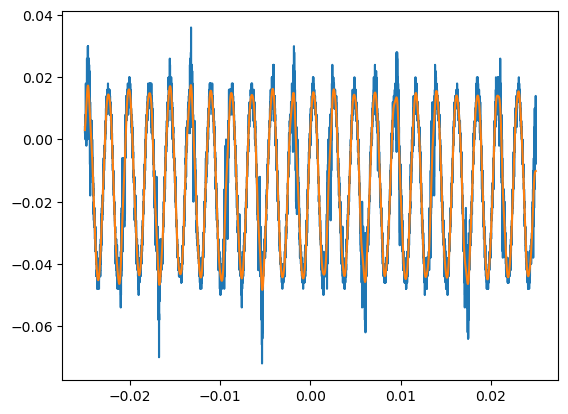

In [4]:
# --!--------------------------------------------------------------------------
# --! remove noise from loaded data

filtered_med = sig.medfilt(v, kernel_size=5)

# --! apply a Butterworth filter and keep signal content up to 2 kHz only
cutoff = 2000
filtered_butter = butter_lowpass_filter(v, cutoff, fs)

plt.figure()
plt.plot(t, v)
plt.plot(t, filtered_butter)
plt.show()

inf >> downsampled data gets a new sampling frequency of 40000.0 Hz
inf >> the new frequency corresponds to a new timestep of 2.5e-05 s


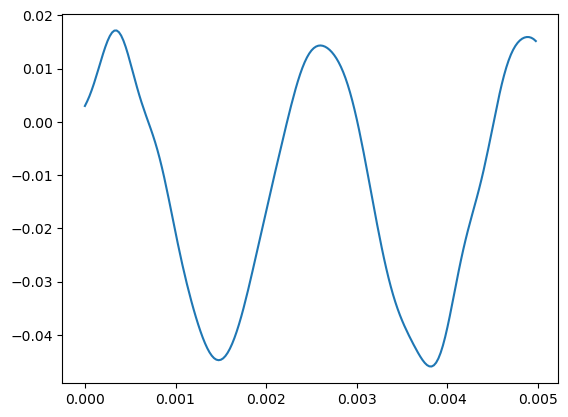

In [5]:
# --! downsample filtered data-------------------------------------------------

# --! the idea to select q is that we would like to have 200 samples that
# --! feature a couple of oscillations
q = 5
train_timeseries_sz = 200

downsampled_data = sig.decimate(filtered_butter, q=q, ftype='iir')

fs_new = fs/q
ts_new = 1/fs_new

t = np.arange(0., train_timeseries_sz*ts_new, ts_new)

print(f'inf >> downsampled data gets a new sampling frequency of {fs_new} Hz')
print(f'inf >> the new frequency corresponds to a new timestep of {ts_new} s')
plt.figure()
plt.plot(t, downsampled_data[:train_timeseries_sz])
plt.show()

In [6]:
# --! save simulation data to files ------------------------------------------!

def sample_timeseries(rng, sample_sz, timeseries_sz, *timeseries_array):
    """
    Given ``timeseries`` are expected to be shaped as one-dimensional arrays [T],
    where T is the number of timesteps.
    """

    # --! select current timeseries
    global timeseries_i
    # take the current timeseries using available index
    timeseries = timeseries_array[timeseries_i]

    # update timeseries index for the next time
    timeseries_i_end = len(timeseries_array) - 1
    if timeseries_i < timeseries_i_end:
        timeseries_i = timeseries_i + 1
    else:
        timeseries_i = 0

    # --! randomly locate a suitable sample region inside selected timeseries
    sample_start = int((timeseries_sz - sample_sz) * rng.random())
    sample_end   = sample_start + sample_sz
    sample       = timeseries[sample_start:sample_end, np.newaxis]

    # --! return a sample with mean removed
    return sample - np.mean(sample, axis=0, keepdims=True)

savedata_train_on = True

if savedata_train_on:

    dataset_dir = 'cavity/train_global_meas'

    savedata_config = [
        # batch size, file name
        (3500, 'train1'),
        (3500, 'train2'),
        (3500, 'train3'),
        (3500, 'train4'),
        (3500, 'train5'),
        (3500, 'train6'),
        (3500, 'train7'),
        (1000, 'valid'),
        (500,  'test')]

    savedata_sz = train_timeseries_sz
    timeseries_sz = len(downsampled_data)

    if savedata_sz < timeseries_sz:

        for this, cfg in enumerate(savedata_config):

            rng = np.random.default_rng(seed=this + 1)
            timeseries_i = 0

            data = np.stack([
                sample_timeseries(
                    rng,
                    savedata_sz,
                    timeseries_sz,
                    downsampled_data[:timeseries_sz]) for _ in range(cfg[0])], axis=0)

            utils.write_datafile(f'{dataset_dir}/{cfg[1]}', data)
        print('inf >> training files saved')
    else:
        print('err >> saved data size must be less than timeseries size!')
else:
    print('wrn >> training file saving is switched off')

inf >> training files saved
